# Lateral Double Quantum Dot with Screening Gates from PHIDL

This notebook builds the same **lateral double quantum dot** used in `03_generate_nextnano_input_from_phidl_layout.ipynb`, adds one screening gate below each plunger body through the PHIDL builder, translates the 2D layout into the 3D process-stack representation, writes a nextnano++ input file, runs a structure-only simulation, and inspects the generated structure outputs.

The screening gates are intentionally body-only:

- `SG1` sits directly below the rectangular body of `P1`.
- `SG2` sits directly below the rectangular body of `P2`.
- The plunger heads are left unscreened.
- The screening gates use their own GDS/process layer and a distinct metal z-layer separated by dielectric from the barrier and plunger layers.


## 0. Setup


### 0.1 Imports


In [6]:
from pathlib import Path
import importlib
import json
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src").exists() and (path / "notebooks").exists()
)
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from phidl import quickplot as qp

from qd_design import (
    LinearDotArrayDevice,
    make_sige_ge_process_stack,
    build_simulation_layout,
    write_nextnano_input_from_template,
)

from src import nextnanopp_tools as nnt
nnt = importlib.reload(nnt)

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)

print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: /Users/robertjovanov/code/qpu-design-automation-toolkit


### 0.2 Helper Functions


In [8]:
def print_json(data):
    print(json.dumps(data, indent=2))


def print_header(title: str):
    print("" + "=" * 80)
    print(title)
    print("=" * 80)


def list_tree(path: Path, max_depth: int = 2):
    path = Path(path)
    if not path.exists():
        print(f"Path does not exist: {path}")
        return

    base_depth = len(path.resolve().parts)
    for p in sorted(path.rglob("*")):
        depth = len(p.resolve().parts) - base_depth
        if depth <= max_depth:
            indent = "  " * max(depth - 1, 0)
            marker = "/" if p.is_dir() else ""
            print(f"{indent}{p.name}{marker}")


def layout_spec_table(layout_spec):
    return pd.DataFrame(
        [
            {
                "name": element["name"],
                "gate_type": element["gate_type"],
                "layer_name": element["layer_name"],
                "voltage_label": element["voltage_label"],
                "x_min_nm": element["x_min_nm"],
                "x_max_nm": element["x_max_nm"],
                "y_min_nm": element["y_min_nm"],
                "y_max_nm": element["y_max_nm"],
                "num_polygons": len(element.get("polygon_xy_nm", [])),
            }
            for element in layout_spec
        ]
    )


def plot_layout_polygons(layout_spec, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8.0, 4.2))

    colors = {
        "plunger": "#D62728",
        "barrier": "#1F77B4",
        "ohmic": "#2CA02C",
        "sensor": "#9467BD",
        "screening": "#8C564B",
    }

    for element in layout_spec:
        color = colors.get(element["gate_type"], "0.45")
        for polygon in element.get("polygon_xy_nm", []):
            points = np.asarray(polygon, dtype=float)
            patch = plt.Polygon(
                points,
                closed=True,
                facecolor=color,
                edgecolor="black",
                linewidth=1.0,
                alpha=0.35,
            )
            ax.add_patch(patch)
        ax.text(
            element["center_x_nm"],
            element["center_y_nm"],
            element["name"],
            ha="center",
            va="center",
            fontsize=8,
            weight="bold",
        )

    x_min = min(element["x_min_nm"] for element in layout_spec)
    x_max = max(element["x_max_nm"] for element in layout_spec)
    y_min = min(element["y_min_nm"] for element in layout_spec)
    y_max = max(element["y_max_nm"] for element in layout_spec)
    pad = 25.0
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (nm)")
    ax.set_ylabel("y (nm)")
    ax.grid(alpha=0.18)
    return ax


### 0.3 Paths and Run Controls


In [23]:
OUTPUT_DIR = REPO_ROOT / "data" / "gds"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENERATED_INPUT_DIR = REPO_ROOT / "configs" / "robert_inputs" / "generated"
GENERATED_INPUT_DIR.mkdir(parents=True, exist_ok=True)

TEMPLATE_INPUT_PATH = REPO_ROOT / "configs" / "robert_inputs" / "double_qd" / "3d" / "Double_Quantum_Dot_3D.in"

GDS_PATH = OUTPUT_DIR / "lateral_double_dot_with_screening_from_phidl.gds"
SVG_PATH = OUTPUT_DIR / "lateral_double_dot_with_screening_from_phidl.svg"
LAYOUT_SPEC_PATH = OUTPUT_DIR / "lateral_double_dot_with_screening_from_phidl_layout_spec.json"
SIMULATION_LAYOUT_PATH = OUTPUT_DIR / "lateral_double_dot_with_screening_from_phidl_simulation_layout.json"
GENERATED_INPUT_PATH = GENERATED_INPUT_DIR / "Lateral_Double_Quantum_Dot_with_Screening_3D_from_PHIDL.in"

RUNS_DIR = REPO_ROOT / "runs"
RUN_TAG = "structure_only_screening_no_solvers"
RUN_SIMULATION = False
BIAS_INDEX = 0

RUN_VARIABLE_OVERRIDES = {
    "strain": 0,
    "poisson": 0,
    "quantum": 0,
    "quantum_poisson": 0,
}

print("Template exists:", TEMPLATE_INPUT_PATH.exists())
print("Template path:", TEMPLATE_INPUT_PATH)
print("Generated input path:", GENERATED_INPUT_PATH)
print("RUN_SIMULATION:", RUN_SIMULATION)
print("RUN_VARIABLE_OVERRIDES:", RUN_VARIABLE_OVERRIDES)


Template exists: True
Template path: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/robert_inputs/double_qd/3d/Double_Quantum_Dot_3D.in
Generated input path: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/robert_inputs/generated/Lateral_Double_Quantum_Dot_with_Screening_3D_from_PHIDL.in
RUN_SIMULATION: False
RUN_VARIABLE_OVERRIDES: {'strain': 0, 'poisson': 0, 'quantum': 0, 'quantum_poisson': 0}


## 1. Build the Lateral Double Dot Layout


### 1.1 Instantiate the Parametric Builder


In [10]:
lateral_dot = LinearDotArrayDevice(
    name="lateral_double_dot_with_screening_from_phidl",
    n_dots=2,

    device_y_size_nm=200.0,

    ohmic_width_nm=40.0,
    ohmic_length_nm=200.0,

    barrier_width_nm=40.0,
    barrier_length_nm=140.0,

    plunger_body_width_nm=40.0,
    plunger_body_length_nm=50.0,
    plunger_head_top_width_nm=60.0,
    plunger_head_max_width_nm=100.0,
    plunger_head_height_nm=100.0,
    plunger_upper_taper_height_nm=25.0,
    plunger_lower_taper_height_nm=25.0,

    ohmic_to_barrier_gap_nm=20.0,
    barrier_to_plunger_gap_nm=20.0,

    include_screening_gates=True,
)

layout = lateral_dot.ensure_built()

print_header("Lateral Double Dot with Screening Device Summary")
print_json(lateral_dot.summary())
print("Layout bbox:", layout.bbox)


Lateral Double Dot with Screening Device Summary
{
  "name": "lateral_double_dot_with_screening_from_phidl",
  "n_dots": 2,
  "device_y_size_nm": 200.0,
  "ohmic_width_nm": 40.0,
  "ohmic_length_nm": 200.0,
  "barrier_width_nm": 40.0,
  "barrier_length_nm": 140.0,
  "plunger_body_width_nm": 40.0,
  "plunger_body_length_nm": 50.0,
  "plunger_head_top_width_nm": 60.0,
  "plunger_head_max_width_nm": 100.0,
  "plunger_head_height_nm": 100.0,
  "plunger_upper_taper_height_nm": 25.0,
  "plunger_lower_taper_height_nm": 25.0,
  "ohmic_to_barrier_gap_nm": 20.0,
  "barrier_to_plunger_gap_nm": 20.0,
  "include_screening_gates": true,
  "screening_gate_width_nm": 40.0,
  "screening_gate_length_nm": 50.0
}
Layout bbox: [[-260.    0.]
 [ 260.  200.]]


### 1.2 Visualize the Layout


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


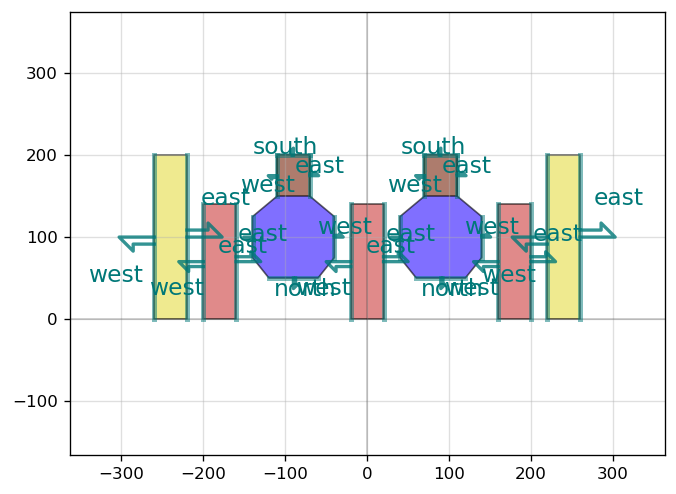

In [11]:
qp(layout)


### 1.3 Matplotlib Footprint Check


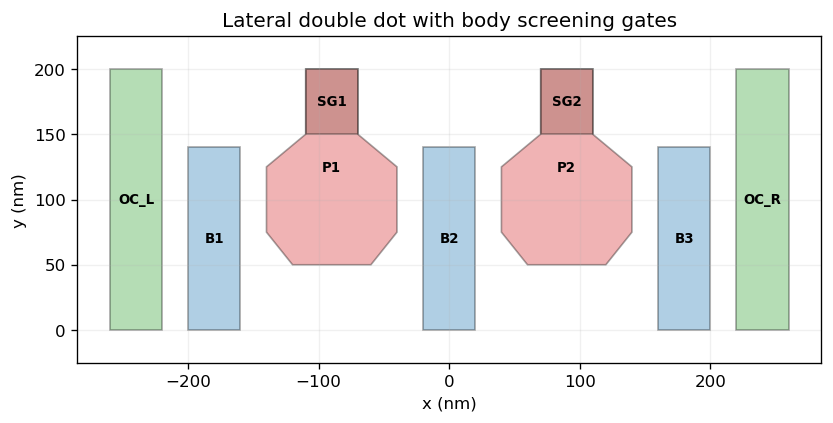

,name,gate_type,layer_name,voltage_label,x_min_nm,x_max_nm,y_min_nm,y_max_nm,num_polygons
0,OC_L,ohmic,ohmic,V_OC_L,-260.0,-220.0,0.0,200.0,1
1,B1,barrier,barrier,V_B1,-200.0,-160.0,0.0,140.0,1
2,P1,plunger,plunger,V_P1,-140.0,-40.0,50.0,200.0,1
3,SG1,screening,screening,V_SG1,-110.0,-70.0,150.0,200.0,1
4,B2,barrier,barrier,V_B2,-20.0,20.0,0.0,140.0,1
5,P2,plunger,plunger,V_P2,40.0,140.0,50.0,200.0,1
6,SG2,screening,screening,V_SG2,70.0,110.0,150.0,200.0,1
7,B3,barrier,barrier,V_B3,160.0,200.0,0.0,140.0,1
8,OC_R,ohmic,ohmic,V_OC_R,220.0,260.0,0.0,200.0,1


In [12]:
layout_spec = lateral_dot.layout_spec()
ax = plot_layout_polygons(layout_spec)
ax.set_title("Lateral double dot with body screening gates")
plt.show()

display(layout_spec_table(layout_spec))


### 1.4 Verify Screening Gate Alignment


In [13]:
layout_by_name = {element["name"]: element for element in layout_spec}
checks = []
for index in (1, 2):
    plunger = layout_by_name[f"P{index}"]
    screen = layout_by_name[f"SG{index}"]
    expected = {
        "x_min_nm": plunger["center_x_nm"] - 0.5 * lateral_dot.plunger_body_width_nm,
        "x_max_nm": plunger["center_x_nm"] + 0.5 * lateral_dot.plunger_body_width_nm,
        "y_min_nm": lateral_dot.device_y_size_nm - lateral_dot.plunger_body_length_nm,
        "y_max_nm": lateral_dot.device_y_size_nm,
    }
    checks.append(
        {
            "screening_gate": screen["name"],
            "under_plunger": plunger["name"],
            "x_matches_body": np.isclose(screen["x_min_nm"], expected["x_min_nm"]) and np.isclose(screen["x_max_nm"], expected["x_max_nm"]),
            "y_matches_body": np.isclose(screen["y_min_nm"], expected["y_min_nm"]) and np.isclose(screen["y_max_nm"], expected["y_max_nm"]),
            "screen_x_min_nm": screen["x_min_nm"],
            "screen_x_max_nm": screen["x_max_nm"],
            "screen_y_min_nm": screen["y_min_nm"],
            "screen_y_max_nm": screen["y_max_nm"],
        }
    )

display(pd.DataFrame(checks))
assert all(row["x_matches_body"] and row["y_matches_body"] for row in checks)


,screening_gate,under_plunger,x_matches_body,y_matches_body,screen_x_min_nm,screen_x_max_nm,screen_y_min_nm,screen_y_max_nm
0,SG1,P1,True,True,-110.0,-70.0,150.0,200.0
1,SG2,P2,True,True,70.0,110.0,150.0,200.0


### 1.5 Export GDS, SVG, and Layout Spec


In [14]:
lateral_dot.write_gds(str(GDS_PATH))
lateral_dot.write_svg(str(SVG_PATH))

with open(LAYOUT_SPEC_PATH, "w", encoding="utf-8") as f:
    json.dump(layout_spec, f, indent=2)

print("Saved GDS:", GDS_PATH)
print("Saved SVG:", SVG_PATH)
print("Saved layout spec:", LAYOUT_SPEC_PATH)


Saved GDS: /Users/robertjovanov/code/qpu-design-automation-toolkit/data/gds/lateral_double_dot_with_screening_from_phidl.gds
Saved SVG: /Users/robertjovanov/code/qpu-design-automation-toolkit/data/gds/lateral_double_dot_with_screening_from_phidl.svg
Saved layout spec: /Users/robertjovanov/code/qpu-design-automation-toolkit/data/gds/lateral_double_dot_with_screening_from_phidl_layout_spec.json


## 2. Build the 3D Simulation Layout


### 2.1 Three-Metal Process Stack with Screening Layer


In [15]:
process_stack = make_sige_ge_process_stack(
    name="SiGe_Ge_QW_three_metal_gate_layers_with_screening",
    al2o3_total_thickness_nm=107.0,

    barrier_gate_thickness_nm=30.0,
    screening_gate_thickness_nm=30.0,
    plunger_gate_thickness_nm=30.0,

    barrier_gate_bottom_z_nm=108.0,
    screening_gate_bottom_z_nm=143.0,
    plunger_gate_bottom_z_nm=178.0,
)

print_header("Process Stack")
print_json(process_stack.to_dict())


Process Stack
{
  "name": "SiGe_Ge_QW_three_metal_gate_layers_with_screening",
  "z_reference_name": "top_of_Ge_QW",
  "z_min_nm": -4015.0,
  "z_max_nm": 208.0,
  "material_layers": [
    {
      "name": "SiGe_buffer",
      "material": "SiGe",
      "z_min_nm": -4015.0,
      "z_max_nm": -15.0,
      "alloy_x": 0.15,
      "notes": null
    },
    {
      "name": "Ge_QW",
      "material": "Ge",
      "z_min_nm": -15.0,
      "z_max_nm": 0.0,
      "alloy_x": null,
      "notes": null
    },
    {
      "name": "SiGe_cap",
      "material": "SiGe",
      "z_min_nm": 0.0,
      "z_max_nm": 101.0,
      "alloy_x": 0.15,
      "notes": null
    },
    {
      "name": "Al2O3_dielectric",
      "material": "Al2O3",
      "z_min_nm": 101.0,
      "z_max_nm": 208.0,
      "alloy_x": null,
      "notes": null
    }
  ],
  "gate_rules": [
    {
      "name": "barrier_gate_rule",
      "applies_to_layer_names": [
        "barrier"
      ],
      "material": "Al",
      "z_min_nm": 108.0,
      

### 2.2 Combine Layout Spec and Process Stack


In [16]:
simulation_layout = build_simulation_layout(
    name="lateral_double_dot_with_screening_simulation_layout",
    layout_elements=layout_spec,
    process_stack=process_stack,
    x_margin_nm=0.0,
    y_margin_nm=0.0,
)

simulation_layout.write_json(str(SIMULATION_LAYOUT_PATH))

print_header("Simulation Layout Domain")
print_json(simulation_layout.domain.to_dict())
print("Saved simulation layout:", SIMULATION_LAYOUT_PATH)


Simulation Layout Domain
{
  "x_min_nm": -260.0,
  "x_max_nm": 260.0,
  "y_min_nm": 0.0,
  "y_max_nm": 200.0,
  "z_min_nm": -4015.0,
  "z_max_nm": 208.0
}
Saved simulation layout: /Users/robertjovanov/code/qpu-design-automation-toolkit/data/gds/lateral_double_dot_with_screening_from_phidl_simulation_layout.json


### 2.3 Inspect Patterned Regions


In [17]:
patterned_rows = [
    {
        "name": region.name,
        "gate_type": region.gate_type,
        "layer_name": region.layer_name,
        "material": region.material,
        "voltage_label": region.voltage_label,
        "x_min_nm": region.x_min_nm,
        "x_max_nm": region.x_max_nm,
        "y_min_nm": region.y_min_nm,
        "y_max_nm": region.y_max_nm,
        "z_min_nm": region.z_min_nm,
        "z_max_nm": region.z_max_nm,
        "num_polygons": len(region.polygon_xy_nm),
    }
    for region in simulation_layout.patterned_regions
]
display(pd.DataFrame(patterned_rows))


,name,gate_type,layer_name,material,voltage_label,x_min_nm,x_max_nm,y_min_nm,y_max_nm,z_min_nm,z_max_nm,num_polygons
0,OC_L,ohmic,ohmic,Al,V_OC_L,-260.0,-220.0,0.0,200.0,-42.0,208.0,1
1,B1,barrier,barrier,Al,V_B1,-200.0,-160.0,0.0,140.0,108.0,138.0,1
2,P1,plunger,plunger,Al,V_P1,-140.0,-40.0,50.0,200.0,178.0,208.0,1
3,SG1,screening,screening,Al,V_SG1,-110.0,-70.0,150.0,200.0,143.0,173.0,1
4,B2,barrier,barrier,Al,V_B2,-20.0,20.0,0.0,140.0,108.0,138.0,1
5,P2,plunger,plunger,Al,V_P2,40.0,140.0,50.0,200.0,178.0,208.0,1
6,SG2,screening,screening,Al,V_SG2,70.0,110.0,150.0,200.0,143.0,173.0,1
7,B3,barrier,barrier,Al,V_B3,160.0,200.0,0.0,140.0,108.0,138.0,1
8,OC_R,ohmic,ohmic,Al,V_OC_R,220.0,260.0,0.0,200.0,-42.0,208.0,1


## 3. Write the nextnano++ Input


### 3.1 Generate the `.in` File from the 3D Template


In [19]:
if not TEMPLATE_INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Template input file not found: {TEMPLATE_INPUT_PATH}"
        "Update TEMPLATE_INPUT_PATH before generating the nextnano input."
    )

voltage_overrides = {
    "V_P1": -3.0,
    "V_P2": -3.0,
    "V_B1": 0.0,
    "V_B2": 0.0,
    "V_B3": 0.0,
    "V_SG1": 0.0,
    "V_SG2": 0.0,
    "V_OC_L": 0.0,
    "V_OC_R": 0.0,
}

write_nextnano_input_from_template(
    simulation_layout=simulation_layout,
    template_path=TEMPLATE_INPUT_PATH,
    output_path=GENERATED_INPUT_PATH,
    voltage_overrides=voltage_overrides,
)

# Make the generated input itself structure-only, not just the staged run input.
generated_input = nnt.load_input_file(GENERATED_INPUT_PATH)
nnt.set_input_variables(generated_input, RUN_VARIABLE_OVERRIDES)
nnt.save_input_file(generated_input, fullpath=GENERATED_INPUT_PATH, overwrite=True)

print("Generated nextnano input file:", GENERATED_INPUT_PATH)


Generated nextnano input file: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/robert_inputs/generated/Lateral_Double_Quantum_Dot_with_Screening_3D_from_PHIDL.in


### 3.2 Input Sanity Checks


In [21]:
text = GENERATED_INPUT_PATH.read_text(encoding="utf-8")
solver_values = {}
for name in RUN_VARIABLE_OVERRIDES:
    match = re.search(rf"^\${name}\s*=\s*([^#\n]+)", text, flags=re.MULTILINE)
    solver_values[name] = match.group(1).strip() if match else None

checks = pd.Series(
    {
        "polygonal_prism count": text.count("polygonal_prism"),
        "patterned region count": len(simulation_layout.patterned_regions),
        "schottky contact count": text.count("schottky{"),
        "has P1 contact": 'name = "P1"' in text,
        "has P2 contact": 'name = "P2"' in text,
        "has SG1 contact": 'name = "SG1"' in text,
        "has SG2 contact": 'name = "SG2"' in text,
        "strain value": solver_values["strain"],
        "poisson value": solver_values["poisson"],
        "quantum value": solver_values["quantum"],
        "quantum_poisson value": solver_values["quantum_poisson"],
        "has quantum run switch": "!WHEN $quantum            quantum{}" in text,
        "top-level quantum blocks": text.count("quantum{"),
    }
)
display(checks.to_frame("value"))

print_header("First 90 Lines of Generated Input")
for i, line in enumerate(text.splitlines()[:90], start=1):
    print(f"{i:04d}: {line}")


,value
polygonal_prism count,9
patterned region count,9
schottky contact count,9
has P1 contact,True
has P2 contact,True
has SG1 contact,True
has SG2 contact,True
strain value,0
poisson value,0
quantum value,0


First 90 Lines of Generated Input
0001: #--------------------------------------
0002: #--- generated gate voltage values ---
0003: #--------------------------------------
0004: $V_OC_L = 0 # (V) generated
0005: $V_B1 = 0 # (V) generated
0006: $V_P1 = -3 # (V) generated
0007: $V_SG1 = 0 # (V) generated
0008: $V_B2 = 0 # (V) generated
0009: $V_P2 = -3 # (V) generated
0010: $V_SG2 = 0 # (V) generated
0011: $V_B3 = 0 # (V) generated
0012: $V_OC_R = 0 # (V) generated
0013: 
0014: # Double Quantum Dot - 3D - Robert Jovanov
0015: 
0016: #----------------------
0017: #--- solver control ---
0018: #----------------------
0019: 
0020: #--- choice of solvers ---
0021: 
0022: $strain = 0
0023: $poisson = 0
0024: $quantum = 0
0025: $quantum_poisson = 0
0026: 
0027: $decomposition = 0 # use decomposition algorithm to solve 3D quantum poisson if set to 1 (quantization on the z direction)
0028: 
0029: #--- numerical parameters for the quantum solver ----
0030: 
0031: $n_c_Ge_QW_HH = 100
0032: $n_c_Ge_

## 4. Run the nextnano Simulation


### 4.1 Execute the Generated Input

This run is configured for structure output only: strain, Poisson, quantum, and quantum-Poisson are all set to `0` in both the generated input and the run overrides.


In [25]:
if RUN_SIMULATION:
    RUNS_DIR.mkdir(parents=True, exist_ok=True)

    input_file = nnt.run_input_file(
        GENERATED_INPUT_PATH,
        output_root=RUNS_DIR,
        tag=RUN_TAG,
        add_timestamp=True,
        variables=RUN_VARIABLE_OVERRIDES,
        show_log=True,
        convergenceCheck=False,
        staging_root=GENERATED_INPUT_DIR / "staged_runs",
        keep_staged_input=True,
    )

    OUTPUT_RUN_DIR = nnt.get_output_directory(input_file)
    print("Simulation launched/completed.")
    print("Output run directory:", OUTPUT_RUN_DIR)
else:
    OUTPUT_RUN_DIR = None
    print("RUN_SIMULATION is False. Set it to True and rerun this cell to execute nextnano.")
    print("Run tag that will be used:", RUN_TAG)


RUN_SIMULATION is False. Set it to True and rerun this cell to execute nextnano.
Run tag that will be used: structure_only_screening_no_solvers


### 4.2 Resolve a Completed Run


In [26]:
RUNS_DIR.mkdir(parents=True, exist_ok=True)

if OUTPUT_RUN_DIR is None:
    matching_runs = nnt.find_runs_for_input(RUNS_DIR, GENERATED_INPUT_PATH)
    tagged_runs = [run for run in matching_runs if RUN_TAG in run.name]
    if tagged_runs:
        matching_runs = tagged_runs
    OUTPUT_RUN_DIR = matching_runs[-1] if matching_runs else None

RUN_AVAILABLE = OUTPUT_RUN_DIR is not None and Path(OUTPUT_RUN_DIR).exists()

if RUN_AVAILABLE:
    OUTPUT_RUN_DIR = nnt.resolve_run_root(OUTPUT_RUN_DIR)
    RUN_PATHS = nnt.get_run_paths(OUTPUT_RUN_DIR)
    BIAS0 = nnt.get_bias_dir(OUTPUT_RUN_DIR, bias=BIAS_INDEX)
    HAS_QUANTUM_OUTPUTS = (BIAS0 / "Quantum").exists() and any((BIAS0 / "Quantum").rglob("*.dat"))

    run_summary = pd.Series(
        {
            "RUN_ROOT": str(OUTPUT_RUN_DIR),
            "RUN_NAME": OUTPUT_RUN_DIR.name,
            "BIAS_FOLDER": str(BIAS0),
            "job_done": (OUTPUT_RUN_DIR / "job_done.txt").exists(),
            "HAS_QUANTUM_OUTPUTS": HAS_QUANTUM_OUTPUTS,
            "N_STRUCTURE_FILES": len(list(RUN_PATHS.structure.glob("*"))) if RUN_PATHS.structure.exists() else 0,
            "N_VTR_FILES_IN_BIAS": len(list(BIAS0.glob("*.vtr"))) if BIAS0.exists() else 0,
            "N_FLD_FILES_IN_BIAS": len(list(BIAS0.glob("*.fld"))) if BIAS0.exists() else 0,
            "N_DAT_FILES_IN_BIAS": len(list(BIAS0.glob("*.dat"))) if BIAS0.exists() else 0,
        }
    )
    display(run_summary.to_frame("value"))
else:
    print(f"No completed run for {GENERATED_INPUT_PATH.stem!r} was found under {RUNS_DIR}.")
    print("Run section 4.1 before using the output-inspection cells below.")


,value
RUN_ROOT,/Users/robertjovanov/code/qpu-design-automatio...
RUN_NAME,Lateral_Double_Quantum_Dot_with_Screening_3D_f...
BIAS_FOLDER,/Users/robertjovanov/code/qpu-design-automatio...
job_done,True
HAS_QUANTUM_OUTPUTS,False
N_STRUCTURE_FILES,20
N_VTR_FILES_IN_BIAS,8
N_FLD_FILES_IN_BIAS,22
N_DAT_FILES_IN_BIAS,0


## 5. Inspect Generated Structure

This section mirrors the structure-inspection part of notebook 04 and intentionally stops at material/contact/region outputs, because the physics solvers are disabled for this run.


### 5.1 Locate the Structure Outputs


In [28]:
if "OUTPUT_RUN_DIR" not in globals() or OUTPUT_RUN_DIR is None:
    matching_runs = nnt.find_runs_for_input(RUNS_DIR, GENERATED_INPUT_PATH)
    tagged_runs = [run for run in matching_runs if RUN_TAG in run.name]
    if tagged_runs:
        matching_runs = tagged_runs
    OUTPUT_RUN_DIR = matching_runs[-1] if matching_runs else None

if OUTPUT_RUN_DIR is None:
    raise FileNotFoundError(f"No matching run found under {RUNS_DIR}")

OUTPUT_RUN_DIR = nnt.resolve_run_root(OUTPUT_RUN_DIR)
STRUCTURE_DIR = OUTPUT_RUN_DIR / "Structure"

print("Output run directory:", OUTPUT_RUN_DIR.resolve())
print("Run exists:", OUTPUT_RUN_DIR.exists())
print("Structure folder exists:", STRUCTURE_DIR.exists())

if not STRUCTURE_DIR.exists():
    raise FileNotFoundError(
        f"Structure folder not found: {STRUCTURE_DIR.resolve()}"
        "Run the nextnano simulation first, or set OUTPUT_RUN_DIR to the completed run folder."
    )

print_header("Structure Folder")
list_tree(STRUCTURE_DIR, max_depth=1)


Output run directory: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Lateral_Double_Quantum_Dot_with_Screening_3D_from_PHIDL__20260623_181030__structure_only_screening_no_solvers
Run exists: True
Structure folder exists: True
Structure Folder
contact_indices.txt
contacts.vtr
contacts_2d_xy_QW.fld
contacts_2d_xz_QW.fld
density_acceptor.vtr
density_acceptor_2d_xy_QW.fld
density_acceptor_2d_xz_QW.fld
density_fixed_charge.vtr
density_fixed_charge_2d_xy_QW.fld
density_fixed_charge_2d_xz_QW.fld
material_indices.txt
materials.vtr
materials_2d_xy_QW.fld
materials_2d_xz_QW.fld
regions_all.vtr
regions_all_2d_xy_QW.fld
regions_all_2d_xz_QW.fld
regions_material.vtr
regions_material_2d_xy_QW.fld
regions_material_2d_xz_QW.fld


### 5.2 Lightweight Readers for nextnano Structure Files


In [36]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import plotly.graph_objects as go
except ImportError:
    go = None
    print(
        "Plotly is needed for the rotatable 3D view. "
        "Install it with `conda install plotly` or `pip install plotly`."
    )

VTR_DATA_ARRAY_RE = re.compile(
    r'<DataArray[^>]*Name\s*=\s*"([^"]+)"[^>]*>(.*?)</DataArray>',
    flags=re.DOTALL,
)
COORDINATE_ARRAY_NAMES = ("X_COORDINATES", "Y_COORDINATES", "Z_COORDINATES")


def read_index_lookup(path: Path) -> pd.DataFrame:
    """Read nextnano `*_indices.txt` lookup tables."""
    path = Path(path)
    if not path.exists():
        return pd.DataFrame(columns=["Index"])
    lookup = pd.read_csv(path, sep=r"\s+")
    lookup["Index"] = lookup["Index"].astype(int)
    return lookup


def read_ascii_vtr_index(path: Path, dtype=np.int32) -> dict:
    """Read a nextnano ASCII `.vtr` rectilinear-grid index output.

    Returns a dictionary with `x`, `y`, `z`, and `values`, where `values` has
    shape `(n_z, n_y, n_x)` and is addressed as `values[z, y, x]`.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)

    text = path.read_text(encoding="utf-8")
    arrays = {}
    for name, body in VTR_DATA_ARRAY_RE.findall(text):
        clean_name = name.strip()
        arr_dtype = np.float64 if clean_name in COORDINATE_ARRAY_NAMES else np.float32
        arrays[clean_name] = np.fromstring(body, sep=" ", dtype=arr_dtype)

    missing = [name for name in COORDINATE_ARRAY_NAMES if name not in arrays]
    if missing:
        raise ValueError(f"Missing coordinate arrays in {path.name}: {missing}")

    data_names = [name for name in arrays if name not in COORDINATE_ARRAY_NAMES]
    if len(data_names) != 1:
        raise ValueError(f"Expected exactly one data array in {path.name}, got {data_names}")

    x, y, z = (arrays[name] for name in COORDINATE_ARRAY_NAMES)
    raw = arrays[data_names[0]]
    expected = len(x) * len(y) * len(z)
    if raw.size != expected:
        raise ValueError(
            f"{path.name}: expected {expected:,} values from grid dimensions, got {raw.size:,}"
        )

    values = np.rint(raw).astype(dtype, copy=False).reshape((len(z), len(y), len(x)))
    return {"path": path, "label": data_names[0], "x": x, "y": y, "z": z, "values": values}


def _read_ascii_values(lines: list[str], start_line: int, count: int, dtype) -> np.ndarray:
    """Read exactly `count` whitespace-separated values from an AVS ASCII block."""
    if count <= 0:
        return np.array([], dtype=dtype)

    # nextnano's AVS writer uses line-based `skip` values. Most outputs place
    # one scalar per line, so start+count is exact and avoids trailing metadata.
    chunk = "\n".join(lines[start_line:start_line + count])
    values = np.fromstring(chunk, sep=" ", dtype=dtype)
    if values.size >= count:
        return values[:count]

    # Fallback for wrapped rows: scan forward until enough numeric values are read.
    chunks = []
    for line in lines[start_line:]:
        stripped = line.strip()
        if not stripped:
            continue
        chunks.append(stripped)
        values = np.fromstring("\n".join(chunks), sep=" ", dtype=dtype)
        if values.size >= count:
            return values[:count]

    raise ValueError(f"expected {count:,} values, got {values.size:,}")


def read_avs_fld(path: Path, dtype=np.int32) -> dict:
    """Read a 2D nextnano AVS/Express `.fld` rectilinear slice."""
    path = Path(path)
    lines = path.read_text(encoding="utf-8").splitlines()
    header = "\n".join(lines[:80])

    def header_int(pattern: str) -> int:
        match = re.search(pattern, header)
        if match is None:
            raise ValueError(f"Could not parse `{pattern}` in {path.name}")
        return int(match.group(1))

    dim1 = header_int(r"dim1\s*=\s*(\d+)")
    dim2 = header_int(r"dim2\s*=\s*(\d+)")
    variable_skip = header_int(r"variable\s+1[^\n]*skip=(\d+)")
    coord1_skip = header_int(r"coord\s+1[^\n]*skip=(\d+)")
    coord2_skip = header_int(r"coord\s+2[^\n]*skip=(\d+)")
    label_match = re.search(r"label\s*=\s*([^\n]+)", header)
    label = label_match.group(1).strip() if label_match else path.stem

    coord1 = _read_ascii_values(lines, coord1_skip, dim1, np.float64)
    coord2 = _read_ascii_values(lines, coord2_skip, dim2, np.float64)
    raw = _read_ascii_values(lines, variable_skip, dim1 * dim2, np.float32)

    values = np.rint(raw).astype(dtype, copy=False).reshape((dim2, dim1))
    return {"path": path, "label": label, "coord1": coord1, "coord2": coord2, "values": values}


def summarize_index_grid(grid: dict, lookup=None, name_column=None) -> pd.DataFrame:
    values = grid["values"]
    unique, counts = np.unique(values, return_counts=True)
    summary = pd.DataFrame(
        {
            "Index": unique.astype(int),
            "grid_points": counts.astype(int),
            "fraction": counts / counts.sum(),
        }
    )

    if lookup is not None and not lookup.empty and name_column in lookup.columns:
        names = lookup.set_index("Index")[name_column].to_dict()
        summary.insert(1, name_column, summary["Index"].map(names).fillna(""))

    return summary


def centers_to_edges(centers: np.ndarray) -> np.ndarray:
    centers = np.asarray(centers, dtype=float)
    if centers.size == 1:
        return np.array([centers[0] - 0.5, centers[0] + 0.5])

    edges = np.empty(centers.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
    edges[0] = centers[0] - 0.5 * (centers[1] - centers[0])
    edges[-1] = centers[-1] + 0.5 * (centers[-1] - centers[-2])
    return edges


def contiguous_runs(indices: np.ndarray) -> list[tuple[int, int]]:
    indices = np.asarray(indices, dtype=int)
    if indices.size == 0:
        return []

    break_positions = np.flatnonzero(np.diff(indices) > 1)
    starts = np.r_[indices[0], indices[break_positions + 1]]
    ends = np.r_[indices[break_positions], indices[-1]]
    return [(int(start), int(end)) for start, end in zip(starts, ends)]


def index_z_intervals(grid: dict, lookup=None, name_column=None) -> pd.DataFrame:
    values = grid["values"]
    z_edges = centers_to_edges(grid["z"])
    rows = []

    for index in sorted(np.unique(values).astype(int)):
        z_profile = np.any(values == index, axis=(1, 2))
        for start, end in contiguous_runs(np.flatnonzero(z_profile)):
            rows.append(
                {
                    "Index": index,
                    "z_min_nm": z_edges[start],
                    "z_max_nm": z_edges[end + 1],
                    "z_grid_points": end - start + 1,
                }
            )

    intervals = pd.DataFrame(rows)
    if lookup is not None and not lookup.empty and name_column in lookup.columns:
        names = lookup.set_index("Index")[name_column].to_dict()
        intervals.insert(1, name_column, intervals["Index"].map(names).fillna(""))

    return intervals


def lookup_index_name(lookup, index: int, name_column) -> str:
    if lookup is None or lookup.empty or name_column not in lookup.columns:
        return f"index {index}"

    matches = lookup.loc[lookup["Index"] == int(index), name_column]
    if matches.empty:
        return f"index {index}"
    return str(matches.iloc[0])


### 5.3 Index Tables and Volume Summaries


In [37]:
material_lookup = read_index_lookup(STRUCTURE_DIR / "material_indices.txt")
contact_lookup = read_index_lookup(STRUCTURE_DIR / "contact_indices.txt")
region_lookup = read_index_lookup(STRUCTURE_DIR / "region_indices.txt")

print_header("Material Index Lookup")
display(material_lookup)

print_header("Contact Index Lookup")
display(contact_lookup)

if region_lookup.empty:
    print("No region_indices.txt file was written in this Structure folder; region outputs are summarized by raw integer index below.")
else:
    print_header("Region Index Lookup")
    display(region_lookup)

print_header("Loading 3D Material and Contact Volumes")
material_grid = read_ascii_vtr_index(STRUCTURE_DIR / "materials.vtr", dtype=np.int16)
contact_grid = read_ascii_vtr_index(STRUCTURE_DIR / "contacts.vtr", dtype=np.int16)
print(
    f"Loaded grid shape (z, y, x): {material_grid['values'].shape}; "
    f"x={len(material_grid['x'])}, y={len(material_grid['y'])}, z={len(material_grid['z'])}"
)

print_header("Material Index Summary")
display(summarize_index_grid(material_grid, material_lookup, "Material"))

print_header("Material z Intervals")
display(index_z_intervals(material_grid, material_lookup, "Material"))

print_header("Contact Index Summary")
display(summarize_index_grid(contact_grid, contact_lookup, "Contact"))

print_header("Contact z Intervals")
display(index_z_intervals(contact_grid, contact_lookup, "Contact"))

print_header("Region Index Summary: regions_all.vtr")
regions_all_summary = summarize_index_grid(
    read_ascii_vtr_index(STRUCTURE_DIR / "regions_all.vtr", dtype=np.int32),
    region_lookup,
    "Region",
)
display(regions_all_summary)

print_header("Region Index Summary: regions_material.vtr")
regions_material_summary = summarize_index_grid(
    read_ascii_vtr_index(STRUCTURE_DIR / "regions_material.vtr", dtype=np.int32),
    region_lookup,
    "Region",
)
display(regions_material_summary)


Material Index Lookup


,Index,Material
0,-1,no_material_defined
1,8,Ge
2,16,Si(x)Ge(1-x)
3,396,Sapphire_zb


Contact Index Lookup


,Index,Contact
0,0,no_contact_defined
1,1,OC_L
2,2,B1
3,3,P1
4,4,SG1
5,5,B2
6,6,P2
7,7,SG2
8,8,B3
9,9,OC_R


No region_indices.txt file was written in this Structure folder; region outputs are summarized by raw integer index below.
Loading 3D Material and Contact Volumes
Loaded grid shape (z, y, x): (2115, 40, 104); x=104, y=40, z=2115
Material Index Summary


...

,Index,Contact,z_min_nm,z_max_nm,z_grid_points
0,0,no_contact_defined,-4009.001465,-15.013393,1998
1,0,no_contact_defined,0.026348,99.019608,50
2,0,no_contact_defined,100.942402,208.000000,55
3,1,OC_L,-42.017731,208.000000,128
4,2,B1,108.062500,137.916664,15
5,3,P1,178.083336,208.000000,15
6,4,SG1,143.083336,172.916664,15
7,5,B2,108.062500,137.916664,15
8,6,P2,178.083336,208.000000,15
9,7,SG2,143.083336,172.916664,15


Region Index Summary: regions_all.vtr


,Index,grid_points,fraction
0,0,8302720,0.943662
1,2,176000,0.020004
2,3,168220,0.019119
3,4,12480,0.001418
4,5,3520,0.000400
5,6,28160,0.003201
6,7,40960,0.004655
7,8,3360,0.000382
8,9,6450,0.000733
9,10,1200,0.000136


Region Index Summary: regions_material.vtr


,Index,grid_points,fraction
0,0,8324160,0.946099
1,1,33280,0.003783
2,2,212160,0.024113
3,3,228800,0.026005


### 5.4 Confirm Screening Contacts in the Structure Output


In [38]:
required_contacts = {"SG1", "SG2", "P1", "P2"}
present_contacts = set(contact_lookup["Contact"].astype(str)) if "Contact" in contact_lookup.columns else set()
missing_contacts = sorted(required_contacts - present_contacts)

contact_checks = pd.Series(
    {
        "has SG1": "SG1" in present_contacts,
        "has SG2": "SG2" in present_contacts,
        "has P1": "P1" in present_contacts,
        "has P2": "P2" in present_contacts,
        "missing required contacts": ", ".join(missing_contacts) if missing_contacts else "",
    }
)
display(contact_checks.to_frame("value"))
assert not missing_contacts


,value
has SG1,True
has SG2,True
has P1,True
has P2,True
missing required contacts,


### 5.5 Rotatable 3D Device Geometry

This Plotly view shows translucent material slabs plus sampled points from each patterned gate/contact. Drag the plot to rotate. The default `z_range_nm` focuses on the active gate stack so the barrier, screening, and plunger layers are visible; set it to `None` in the cell below to show the full simulation depth.


In [39]:
MATERIAL_COLORS = {
    -1: "#d9d9d9",  # no_material_defined
    8: "#4daf4a",   # Ge
    16: "#377eb8",  # SiGe
    396: "#bdbdbd", # Sapphire_zb / Al2O3
}
CONTACT_COLOR_SEQUENCE = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#a65628", "#f781bf", "#999999", "#66c2a5", "#fc8d62",
]


def add_box_mesh(fig, x_range, y_range, z_range, name, color, opacity=0.18):
    x0, x1 = x_range
    y0, y1 = y_range
    z0, z1 = z_range
    vertices = np.array(
        [
            [x0, y0, z0], [x1, y0, z0], [x1, y1, z0], [x0, y1, z0],
            [x0, y0, z1], [x1, y0, z1], [x1, y1, z1], [x0, y1, z1],
        ]
    )
    faces = np.array(
        [
            [0, 1, 2], [0, 2, 3],
            [4, 6, 5], [4, 7, 6],
            [0, 4, 5], [0, 5, 1],
            [1, 5, 6], [1, 6, 2],
            [2, 6, 7], [2, 7, 3],
            [3, 7, 4], [3, 4, 0],
        ]
    )
    fig.add_trace(
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            name=name,
            color=color,
            opacity=opacity,
            hovertemplate=f"{name}<extra></extra>",
            showscale=False,
        )
    )


def sample_contact_points(contact_grid, contact_index, z_range_nm=None, max_points=3000):
    values = contact_grid["values"]
    mask = values == int(contact_index)
    if z_range_nm is not None:
        z_min, z_max = z_range_nm
        z_mask = (contact_grid["z"] >= z_min) & (contact_grid["z"] <= z_max)
        mask = mask & z_mask[:, None, None]

    zz, yy, xx = np.nonzero(mask)
    if xx.size == 0:
        return None

    if max_points is not None and xx.size > max_points:
        selection = np.linspace(0, xx.size - 1, max_points, dtype=int)
        zz, yy, xx = zz[selection], yy[selection], xx[selection]

    return contact_grid["x"][xx], contact_grid["y"][yy], contact_grid["z"][zz]


def plot_structure_3d(
    material_grid,
    contact_grid,
    material_lookup=None,
    contact_lookup=None,
    contact_ids=None,
    z_range_nm=(-120, 215),
    max_points_per_contact=3000,
):
    if go is None:
        raise ImportError("Plotly is required for the rotatable 3D structure view.")

    fig = go.Figure()
    x_edges = centers_to_edges(material_grid["x"])
    y_edges = centers_to_edges(material_grid["y"])
    material_intervals = index_z_intervals(material_grid, material_lookup, "Material")

    for _, row in material_intervals.iterrows():
        z0, z1 = float(row["z_min_nm"]), float(row["z_max_nm"])
        if z_range_nm is not None:
            view_z0, view_z1 = z_range_nm
            if z1 < view_z0 or z0 > view_z1:
                continue
            z0, z1 = max(z0, view_z0), min(z1, view_z1)

        index = int(row["Index"])
        material_name = lookup_index_name(material_lookup, index, "Material")
        add_box_mesh(
            fig,
            (x_edges[0], x_edges[-1]),
            (y_edges[0], y_edges[-1]),
            (z0, z1),
            name=f"material {index}: {material_name}",
            color=MATERIAL_COLORS.get(index, "#cccccc"),
            opacity=0.16,
        )

    if contact_ids is None:
        contact_ids = [int(i) for i in sorted(np.unique(contact_grid["values"])) if int(i) != 0]

    for color_i, contact_index in enumerate(contact_ids):
        sampled = sample_contact_points(
            contact_grid,
            contact_index,
            z_range_nm=z_range_nm,
            max_points=max_points_per_contact,
        )
        if sampled is None:
            continue

        xs, ys, zs = sampled
        contact_name = lookup_index_name(contact_lookup, contact_index, "Contact")
        color = CONTACT_COLOR_SEQUENCE[color_i % len(CONTACT_COLOR_SEQUENCE)]
        fig.add_trace(
            go.Scatter3d(
                x=xs,
                y=ys,
                z=zs,
                mode="markers",
                name=f"contact {contact_index}: {contact_name}",
                marker={"size": 2.5, "color": color, "opacity": 0.85},
                hovertemplate=(
                    f"contact {contact_index}: {contact_name}<br>"
                    "x=%{x:.1f} nm<br>y=%{y:.1f} nm<br>z=%{z:.1f} nm<extra></extra>"
                ),
            )
        )

    title = "Simulated 3D lateral double dot with screening gates"
    if z_range_nm is not None:
        title += f" (z = {z_range_nm[0]} to {z_range_nm[1]} nm)"

    fig.update_layout(
        title=title,
        height=760,
        margin={"l": 0, "r": 0, "t": 48, "b": 0},
        legend={"itemsizing": "constant"},
        scene={
            "xaxis_title": "x (nm)",
            "yaxis_title": "y (nm)",
            "zaxis_title": "z (nm)",
            "aspectmode": "manual",
            "aspectratio": {"x": 1.55, "y": 0.65, "z": 1.0},
            "camera": {"eye": {"x": 1.55, "y": -1.45, "z": 1.0}},
        },
    )
    return fig


surface_gate_names = ["OC_L", "B1", "P1", "SG1", "B2", "P2", "SG2", "B3", "OC_R"]
contact_name_to_index = dict(zip(contact_lookup["Contact"], contact_lookup["Index"]))
surface_gate_ids = [contact_name_to_index[name] for name in surface_gate_names if name in contact_name_to_index]

structure_fig = plot_structure_3d(
    material_grid,
    contact_grid,
    material_lookup=material_lookup,
    contact_lookup=contact_lookup,
    contact_ids=surface_gate_ids,
    z_range_nm=(-120, 215),
    max_points_per_contact=3500,
)
structure_fig.show()

# To include auxiliary contacts as well, use:
# all_contact_ids = [int(i) for i in contact_lookup["Index"] if int(i) != 0]
# plot_structure_3d(material_grid, contact_grid, material_lookup, contact_lookup, all_contact_ids).show()

# To show the full z depth instead of the active stack, set z_range_nm=None:
# plot_structure_3d(material_grid, contact_grid, material_lookup, contact_lookup, surface_gate_ids, z_range_nm=None).show()


### 5.6 2D Structural Slices


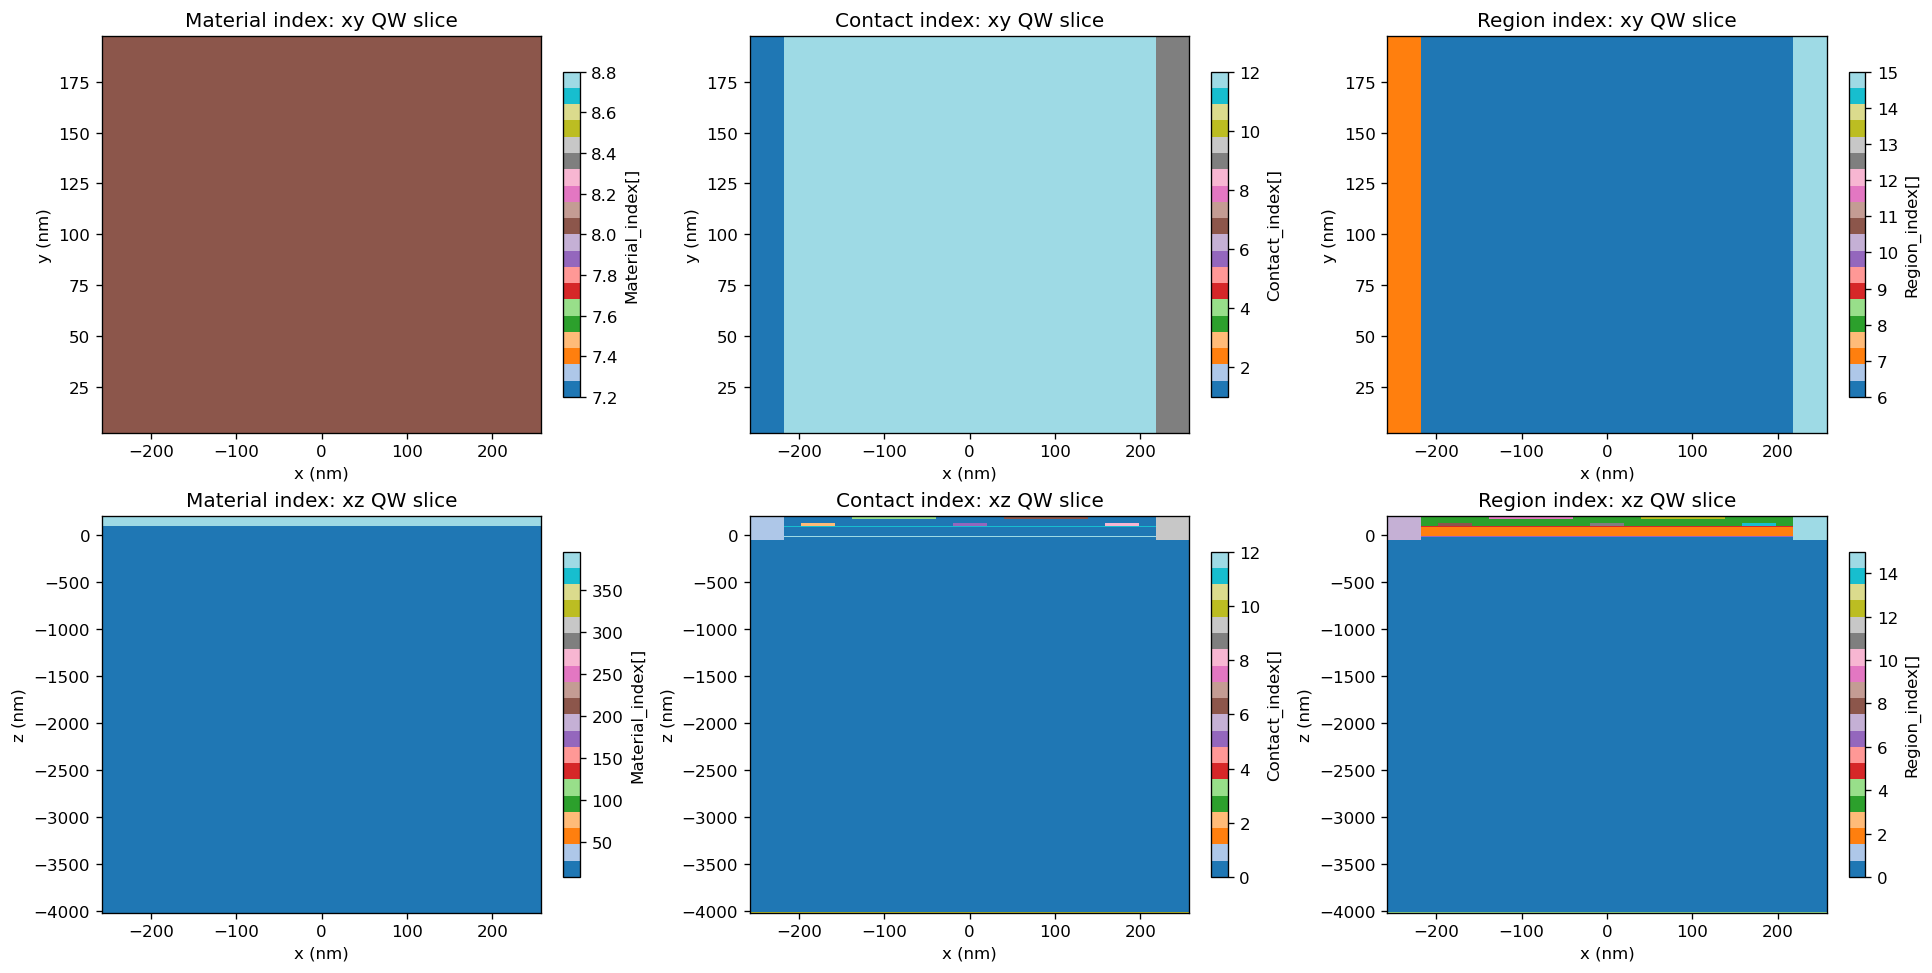

In [40]:
def infer_slice_axes(path: Path):
    stem = Path(path).stem
    if "_xy_" in stem:
        return "x", "y"
    if "_xz_" in stem:
        return "x", "z"
    if "_yz_" in stem:
        return "y", "z"
    return "coord1", "coord2"


def plot_fld_index_slice(path: Path, ax=None, title=None, cmap="tab20"):
    data = read_avs_fld(path)
    axis1, axis2 = infer_slice_axes(path)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))

    image = ax.imshow(
        data["values"],
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        extent=[data["coord1"].min(), data["coord1"].max(), data["coord2"].min(), data["coord2"].max()],
        cmap=cmap,
    )
    ax.set_title(title or path.name)
    ax.set_xlabel(f"{axis1} (nm)")
    ax.set_ylabel(f"{axis2} (nm)")
    plt.colorbar(image, ax=ax, shrink=0.82, label=data["label"])
    return ax


slice_specs = [
    (STRUCTURE_DIR / "materials_2d_xy_QW.fld", "Material index: xy QW slice"),
    (STRUCTURE_DIR / "contacts_2d_xy_QW.fld", "Contact index: xy QW slice"),
    (STRUCTURE_DIR / "regions_all_2d_xy_QW.fld", "Region index: xy QW slice"),
    (STRUCTURE_DIR / "materials_2d_xz_QW.fld", "Material index: xz QW slice"),
    (STRUCTURE_DIR / "contacts_2d_xz_QW.fld", "Contact index: xz QW slice"),
    (STRUCTURE_DIR / "regions_all_2d_xz_QW.fld", "Region index: xz QW slice"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for ax, (path, title) in zip(axes.ravel(), slice_specs):
    if path.exists():
        plot_fld_index_slice(path, ax=ax, title=title)
    else:
        ax.set_axis_off()
        ax.set_title(f"Missing: {path.name}")
plt.show()


## 6. Inspect Physical Outputs

This section follows the physical-output workflow from notebook 04 and adapts the default diagnostics to the lateral double-dot axis. The default 1D line cut runs along `x` through the plunger heads while fixing `y = 100 nm` and `z = -2 nm`.

The current structure-only run can still contain bias-level potential, band-edge, and carrier-density outputs. Dedicated quantum-output cells require a run that actually wrote `bias_00000/Quantum/...`; if the current run has no quantum folder, those cells print a short message instead of failing.


### 6.1 Physical Output Setup


In [ ]:
import importlib
import nextnanopp_tools as nnt

# During notebook development, reload the local helper module so newly added
# functions are visible without restarting the kernel.
nnt = importlib.reload(nnt)

list_variables = nnt.list_variables
plot_bias_volume_3d = nnt.plot_bias_volume_3d
plot_bias_volume_slice = nnt.plot_bias_volume_slice
plot_vtr_linecut = nnt.plot_vtr_linecut
resolve_bias_output_file = nnt.resolve_bias_output_file
resolve_quantum_output_file = nnt.resolve_quantum_output_file
resolve_quantum_probability_state_file = nnt.resolve_quantum_probability_state_file
plot_quantum_occupation = nnt.plot_quantum_occupation
plot_quantum_energy_spectrum = nnt.plot_quantum_energy_spectrum
plot_quantum_density_volume_3d = nnt.plot_quantum_density_volume_3d
plot_quantum_density_volume_slice = nnt.plot_quantum_density_volume_slice
plot_quantum_density_volume_linecut = nnt.plot_quantum_density_volume_linecut
plot_quantum_probability_volume_3d = nnt.plot_quantum_probability_volume_3d
plot_quantum_probability_volume_slice = nnt.plot_quantum_probability_volume_slice
plot_quantum_probability_volume_linecut = nnt.plot_quantum_probability_volume_linecut

RUNS_DIR = Path(globals().get("RUNS_DIR", Path("../../runs"))).resolve()

if "OUTPUT_RUN_DIR" not in globals() or OUTPUT_RUN_DIR is None or not Path(OUTPUT_RUN_DIR).exists():
    matching_runs = [
        p for p in RUNS_DIR.iterdir()
        if p.is_dir() and GENERATED_INPUT_PATH.stem in p.name
    ]
    if "RUN_TAG" in globals():
        tagged_runs = [p for p in matching_runs if RUN_TAG in p.name]
        if tagged_runs:
            matching_runs = tagged_runs
    if not matching_runs:
        raise FileNotFoundError(f"No matching runs found under {RUNS_DIR}")
    OUTPUT_RUN_DIR = max(matching_runs, key=lambda p: p.stat().st_mtime)
else:
    OUTPUT_RUN_DIR = Path(OUTPUT_RUN_DIR).resolve()

OUTPUT_RUN_DIR = nnt.resolve_run_root(OUTPUT_RUN_DIR)
BIAS_INDEX = 0
BIAS0 = nnt.get_bias_dir(OUTPUT_RUN_DIR, bias=BIAS_INDEX)
QUANTUM_ROOT = BIAS0 / "Quantum"
HAS_QUANTUM_OUTPUTS = QUANTUM_ROOT.exists() and any(QUANTUM_ROOT.rglob("*"))

# DEFAULT_1D_LINE_DIAGNOSTIC: edit these two values to move every default 1D line cut.
# For this lateral layout, the useful trace follows the transport/interdot x-axis
# through the plunger heads, near the QW.
DEFAULT_1D_LINE_AXIS = "x"
DEFAULT_1D_LINE_FIXED_COORDS = {"y": 100.0, "z": -2.0}

QUANTUM_REGION = "c-Ge_QW"
QUANTUM_BAND = "HH"
QUANTUM_KPOINT = "k00000"
QUANTUM_STATE = 1

available_outputs = {
    "density_hole.vtr": (BIAS0 / "density_hole.vtr").exists(),
    "density_electron.vtr": (BIAS0 / "density_electron.vtr").exists(),
    "potential.vtr": (BIAS0 / "potential.vtr").exists(),
    "bandedges.vtr": (BIAS0 / "bandedges.vtr").exists(),
    "Quantum folder": HAS_QUANTUM_OUTPUTS,
}

print("Physics run directory:", OUTPUT_RUN_DIR.resolve())
print("Bias directory:", BIAS0.resolve())
display(pd.Series(available_outputs).to_frame("available"))

if not HAS_QUANTUM_OUTPUTS:
    print(
        "No quantum-output folder was found for this run. "
        "Run a quantum-enabled input before using section 6.6."
    )


### 6.2 Hole Density Volume, Slices, and 1D Line Cut

Start with `density_hole.vtr`, the full 3D hole-density output in `bias_00000`. The first plot is a downsampled 3D Plotly volume focused around the quantum well. The second plot extracts an exact 2D plane from the same VTR file. Change `slice_axis` and `slice_value` to inspect arbitrary cuts.


In [ ]:
DENSITY_HOLE_VTR = resolve_bias_output_file(
    OUTPUT_RUN_DIR,
    "density_hole",
    bias=BIAS_INDEX,
    preferred_extensions=("vtr",),
)

print("Hole-density VTR:", DENSITY_HOLE_VTR.resolve())
print("Variables:", list_variables(DENSITY_HOLE_VTR))


#### 6.2.1 Default 1D Line-Cut Helper <!-- DEFAULT_1D_LINE_DIAGNOSTIC -->

The default diagnostic follows the lateral device axis (`x`) while fixing `y = 100 nm` through the plunger-head centers and `z = -2 nm` in the quantum-well region. Change `DEFAULT_1D_LINE_AXIS` or `DEFAULT_1D_LINE_FIXED_COORDS` in the setup cell above to reuse the same diagnostic cells for another trace.


In [ ]:
# DEFAULT_1D_LINE_DIAGNOSTIC

def _format_fixed_coords_for_title(fixed_coords):
    return ", ".join(f"{name}={value:g} nm" for name, value in fixed_coords.items())


def plot_default_1d_diagnostic(
    quantity,
    variable,
    *,
    axis=None,
    fixed_coords=None,
    bias=None,
    yscale="linear",
    title=None,
):
    """Plot one editable 1D VTR diagnostic using the shared notebook defaults."""
    axis = DEFAULT_1D_LINE_AXIS if axis is None else axis
    fixed_coords = dict(DEFAULT_1D_LINE_FIXED_COORDS if fixed_coords is None else fixed_coords)
    bias = BIAS_INDEX if bias is None else bias
    path = resolve_bias_output_file(
        OUTPUT_RUN_DIR,
        quantity,
        bias=bias,
        preferred_extensions=("vtr",),
    )
    coord_label = _format_fixed_coords_for_title(fixed_coords)
    plot_title = title or f"{variable} along {axis} ({coord_label})"
    fig = plot_vtr_linecut(
        path,
        variable=variable,
        axis=axis,
        fixed_coords=fixed_coords,
        title=plot_title,
        interactive=True,
        yscale=yscale,
    )
    print(f"{quantity}/{variable}: {axis}-line with requested fixed coordinates {fixed_coords}")
    return fig


In [ ]:
# 3D overview of the hole density. The z range focuses on the quantum-well region;
# use coord_ranges=None to render a heavily downsampled view of the full simulated z domain.
hole_density_volume_fig = plot_bias_volume_3d(
    OUTPUT_RUN_DIR,
    "density_hole",
    bias=BIAS_INDEX,
    variable="Hole_density",
    title="Hole density near the quantum well",
    log10=False,
    coord_ranges={"z": (-30.0, 170.0)},
    max_points=150_000,
    mode="volume",       # use "isosurface" for sharper density contours
    opacity=0.18,
    surface_count=10,
)


In [ ]:
# Exact 2D plane extracted from density_hole.vtr.
# Fix z near the QW midpoint to get the lateral x-y hole-density profile.
hole_density_qw_slice_fig = plot_bias_volume_slice(
    OUTPUT_RUN_DIR,
    "density_hole",
    bias=BIAS_INDEX,
    variable="Hole_density",
    slice_axis="z",
    slice_value=-2.0,
    interactive=True,
    log10=False,
)


In [ ]:
# Other useful cuts through the same 3D VTR volume:

plot_bias_volume_slice(
    OUTPUT_RUN_DIR, "density_hole", bias=BIAS_INDEX, variable="Hole_density",
    slice_axis="y", slice_value=100.0, interactive=True, log10=False,
)

plot_bias_volume_slice(
    OUTPUT_RUN_DIR, "density_hole", bias=BIAS_INDEX, variable="Hole_density",
    slice_axis="x", slice_value=0.0, interactive=True, log10=False,
)


In [ ]:
# DEFAULT_1D_LINE_DIAGNOSTIC
hole_density_linecut_fig = plot_default_1d_diagnostic(
    "density_hole",
    "Hole_density",
    title="Hole density along the lateral device axis (y=100 nm, z=-2 nm)",
)


### 6.3 Electron Density Volume, Slices, and 1D Line Cut

Same workflow as the hole density, now using `density_electron.vtr`. The QW-plane slice fixes `z = -2 nm` to show the lateral electron-density profile.


In [ ]:
DENSITY_ELECTRON_VTR = resolve_bias_output_file(
    OUTPUT_RUN_DIR,
    "density_electron",
    bias=BIAS_INDEX,
    preferred_extensions=("vtr",),
)

print("Electron-density VTR:", DENSITY_ELECTRON_VTR.resolve())
print("Variables:", list_variables(DENSITY_ELECTRON_VTR))


In [ ]:
# 3D overview of the electron density near the quantum-well region.
electron_density_volume_fig = plot_bias_volume_3d(
    OUTPUT_RUN_DIR,
    "density_electron",
    bias=BIAS_INDEX,
    variable="Electron_density",
    title="Electron density near the quantum well",
    log10=False,
    coord_ranges={"z": (-30.0, 170.0)},
    max_points=150_000,
    mode="volume",
    opacity=0.18,
    surface_count=10,
)


In [ ]:
# Exact x-y QW-plane slice extracted from density_electron.vtr.
electron_density_qw_slice_fig = plot_bias_volume_slice(
    OUTPUT_RUN_DIR,
    "density_electron",
    bias=BIAS_INDEX,
    variable="Electron_density",
    slice_axis="z",
    slice_value=-2.0,
    interactive=True,
    log10=False,
)


In [ ]:
# DEFAULT_1D_LINE_DIAGNOSTIC
electron_density_linecut_fig = plot_default_1d_diagnostic(
    "density_electron",
    "Electron_density",
    title="Electron density along the lateral device axis (y=100 nm, z=-2 nm)",
)


### 6.4 Electrostatic Potential Volume, Slices, and 1D Line Cut

Use `potential.vtr` for the same 3D view and exact QW-plane cut. Potential is signed, so this plot uses linear values rather than `log10`.


In [ ]:
POTENTIAL_VTR = resolve_bias_output_file(
    OUTPUT_RUN_DIR,
    "potential",
    bias=BIAS_INDEX,
    preferred_extensions=("vtr",),
)

print("Potential VTR:", POTENTIAL_VTR.resolve())
print("Variables:", list_variables(POTENTIAL_VTR))


In [ ]:
# 3D overview of the electrostatic potential near the quantum-well region.
potential_volume_fig = plot_bias_volume_3d(
    OUTPUT_RUN_DIR,
    "potential",
    bias=BIAS_INDEX,
    variable="Potential",
    title="Electrostatic potential near the quantum well",
    log10=False,
    coord_ranges={"z": (-30.0, 10.0)},
    max_points=150_000,
    mode="volume",
    opacity=0.18,
    surface_count=10,
)


In [ ]:
# Exact x-y QW-plane slice extracted from potential.vtr.
potential_qw_slice_fig = plot_bias_volume_slice(
    OUTPUT_RUN_DIR,
    "potential",
    bias=BIAS_INDEX,
    variable="Potential",
    slice_axis="z",
    slice_value=-2.0,
    interactive=True,
    log10=False,
)


In [ ]:
# DEFAULT_1D_LINE_DIAGNOSTIC
potential_linecut_fig = plot_default_1d_diagnostic(
    "potential",
    "Potential",
    title="Electrostatic potential along the lateral device axis (y=100 nm, z=-2 nm)",
)


### 6.5 Band Edges Volume, Slices, and 1D Line Cuts

`bandedges.vtr` contains multiple variables and is much larger than the density/potential files. The cells below intentionally load one component at a time. Start with the HH band edge because it is usually the most relevant valence-band component for hole confinement, then run other components as needed.


In [ ]:
BANDEDGES_VTR = resolve_bias_output_file(
    OUTPUT_RUN_DIR,
    "bandedges",
    bias=BIAS_INDEX,
    preferred_extensions=("vtr",),
)

print("Band-edges VTR:", BANDEDGES_VTR.resolve())
print("Variables:", list_variables(BANDEDGES_VTR))


In [ ]:
# HH band edge: 3D overview near the quantum-well region.
hh_bandedges_volume_fig = plot_bias_volume_3d(
    OUTPUT_RUN_DIR,
    "bandedges",
    bias=BIAS_INDEX,
    variable="HH",
    title="HH band edge near the quantum well",
    log10=False,
    coord_ranges={"z": (-30.0, 10.0)},
    max_points=150_000,
    mode="volume",
    opacity=0.18,
    surface_count=10,
)


In [ ]:
# HH band edge: exact x-y QW-plane slice.
hh_bandedges_qw_slice_fig = plot_bias_volume_slice(
    OUTPUT_RUN_DIR,
    "bandedges",
    bias=BIAS_INDEX,
    variable="HH",
    title="HH band edge at the QW plane",
    slice_axis="z",
    slice_value=-2.0,
    interactive=True,
    log10=False,
)


In [ ]:
# LH and SO band-edge slices at the same QW plane.
lh_bandedges_qw_slice_fig = plot_bias_volume_slice(
    OUTPUT_RUN_DIR,
    "bandedges",
    bias=BIAS_INDEX,
    variable="LH",
    title="LH band edge at the QW plane",
    slice_axis="z",
    slice_value=-2.0,
    interactive=True,
    log10=False,
)

so_bandedges_qw_slice_fig = plot_bias_volume_slice(
    OUTPUT_RUN_DIR,
    "bandedges",
    bias=BIAS_INDEX,
    variable="SO",
    title="SO band edge at the QW plane",
    slice_axis="z",
    slice_value=-2.0,
    interactive=True,
    log10=False,
)


In [ ]:
# DEFAULT_1D_LINE_DIAGNOSTIC
bandedge_linecut_figs = {}
for bandedge_variable in ("HH", "LH", "SO"):
    bandedge_linecut_figs[bandedge_variable] = plot_default_1d_diagnostic(
        "bandedges",
        bandedge_variable,
        title=f"{bandedge_variable} band edge along the lateral device axis (y=100 nm, z=-2 nm)",
    )


In [ ]:
# Optional electron-relevant band-edge slices. Run these if you want conduction-band checks too.
#
# gamma_bandedges_qw_slice_fig = plot_bias_volume_slice(
#     OUTPUT_RUN_DIR, "bandedges", bias=BIAS_INDEX, variable="Gamma",
#     title="Gamma band edge at the QW plane", slice_axis="z", slice_value=-2.0,
#     interactive=True, log10=False,
# )
#
# delta1_bandedges_qw_slice_fig = plot_bias_volume_slice(
#     OUTPUT_RUN_DIR, "bandedges", bias=BIAS_INDEX, variable="Delta_1",
#     title="Delta_1 band edge at the QW plane", slice_axis="z", slice_value=-2.0,
#     interactive=True, log10=False,
# )
#
# l1_bandedges_qw_slice_fig = plot_bias_volume_slice(
#     OUTPUT_RUN_DIR, "bandedges", bias=BIAS_INDEX, variable="L_1",
#     title="L_1 band edge at the QW plane", slice_axis="z", slice_value=-2.0,
#     interactive=True, log10=False,
# )


In [ ]:
# DEFAULT_1D_LINE_DIAGNOSTIC
# Optional conduction-band 1D diagnostics. Uncomment the variables you want to inspect.
#
# for bandedge_variable in ("Gamma", "Delta_1", "L_1"):
#     bandedge_linecut_figs[bandedge_variable] = plot_default_1d_diagnostic(
#         "bandedges",
#         bandedge_variable,
#         title=f"{bandedge_variable} band edge along the lateral device axis (y=100 nm, z=-2 nm)",
#     )


### 6.6 Quantum Outputs: Density, Probability, Occupation, and Spectrum

These cells use the quantum-output helpers in `nextnanopp_tools`. They inspect the quantum density and the shifted probability for a selected state in 3D, 2D, and 1D. For the current default structure-only run, this section will report that no quantum folder is available. Enable `$quantum` or `$quantum_poisson` and rerun nextnano to populate `bias_00000/Quantum/...`.


In [ ]:
if HAS_QUANTUM_OUTPUTS:
    print("Quantum root:", QUANTUM_ROOT.resolve())
    list_tree(QUANTUM_ROOT, max_depth=3)

    QUANTUM_DENSITY_VTR = resolve_quantum_output_file(
        OUTPUT_RUN_DIR,
        "density",
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        bias=BIAS_INDEX,
        preferred_extensions=("vtr",),
    )
    QUANTUM_PROBABILITY_VTR = resolve_quantum_probability_state_file(
        OUTPUT_RUN_DIR,
        state=QUANTUM_STATE,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        kpoint=QUANTUM_KPOINT,
        shifted=True,
        bias=BIAS_INDEX,
        preferred_extensions=("vtr",),
    )

    print("Quantum density VTR:", QUANTUM_DENSITY_VTR.resolve())
    print("Quantum density variables:", list_variables(QUANTUM_DENSITY_VTR))
    print("Quantum probability VTR:", QUANTUM_PROBABILITY_VTR.resolve())
    print("Quantum probability variables:", list_variables(QUANTUM_PROBABILITY_VTR))
else:
    QUANTUM_DENSITY_VTR = None
    QUANTUM_PROBABILITY_VTR = None
    print(
        "No quantum outputs found. Set RUN_VARIABLE_OVERRIDES to enable quantum output "
        "(for example with quantum=1, and Poisson/quantum-Poisson as needed), then rerun section 4."
    )


In [ ]:
# Quantum density: 3D volume, 2D QW-plane slice, and default 1D line cut.
if HAS_QUANTUM_OUTPUTS:
    quantum_density_volume_fig = plot_quantum_density_volume_3d(
        OUTPUT_RUN_DIR,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        bias=BIAS_INDEX,
        variable=None,
        title=f"Quantum {QUANTUM_BAND} density near the QW",
        log10=False,
        coord_ranges={"z": (-30.0, 10.0)},
        max_points=150_000,
        mode="volume",
        opacity=0.18,
        surface_count=10,
    )

    quantum_density_qw_slice_fig = plot_quantum_density_volume_slice(
        OUTPUT_RUN_DIR,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        bias=BIAS_INDEX,
        variable=None,
        slice_axis="z",
        slice_value=-2.0,
        title=f"Quantum {QUANTUM_BAND} density at the QW plane",
        interactive=True,
        log10=False,
    )

    quantum_density_linecut_fig = plot_quantum_density_volume_linecut(
        OUTPUT_RUN_DIR,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        bias=BIAS_INDEX,
        variable=None,
        axis=DEFAULT_1D_LINE_AXIS,
        fixed_coords=DEFAULT_1D_LINE_FIXED_COORDS,
        title=f"Quantum {QUANTUM_BAND} density along the lateral device axis",
        interactive=True,
    )
else:
    print("Skipped quantum-density plots because no quantum outputs are available for this run.")


In [ ]:
# Shifted probability for the selected state: 3D volume, 2D QW-plane slice, and 1D line cut.
if HAS_QUANTUM_OUTPUTS:
    quantum_probability_volume_fig = plot_quantum_probability_volume_3d(
        OUTPUT_RUN_DIR,
        state=QUANTUM_STATE,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        kpoint=QUANTUM_KPOINT,
        shifted=True,
        bias=BIAS_INDEX,
        variable=None,
        title=f"{QUANTUM_BAND} shifted probability state {QUANTUM_STATE}",
        log10=False,
        coord_ranges={"z": (-30.0, 10.0)},
        max_points=150_000,
        mode="volume",
        opacity=0.18,
        surface_count=10,
    )

    quantum_probability_qw_slice_fig = plot_quantum_probability_volume_slice(
        OUTPUT_RUN_DIR,
        state=QUANTUM_STATE,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        kpoint=QUANTUM_KPOINT,
        shifted=True,
        bias=BIAS_INDEX,
        variable=None,
        slice_axis="z",
        slice_value=-2.0,
        title=f"{QUANTUM_BAND} shifted probability state {QUANTUM_STATE} at the QW plane",
        interactive=True,
        log10=False,
    )

    quantum_probability_linecut_fig = plot_quantum_probability_volume_linecut(
        OUTPUT_RUN_DIR,
        state=QUANTUM_STATE,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        kpoint=QUANTUM_KPOINT,
        shifted=True,
        bias=BIAS_INDEX,
        variable=None,
        axis=DEFAULT_1D_LINE_AXIS,
        fixed_coords=DEFAULT_1D_LINE_FIXED_COORDS,
        title=f"{QUANTUM_BAND} shifted probability state {QUANTUM_STATE} along the lateral device axis",
        interactive=True,
    )
else:
    print("Skipped quantum-probability plots because no quantum outputs are available for this run.")


In [ ]:
# Quantum occupation and energy spectrum diagnostics.
if HAS_QUANTUM_OUTPUTS:
    quantum_occupation_fig = plot_quantum_occupation(
        OUTPUT_RUN_DIR,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        bias=BIAS_INDEX,
        interactive=True,
    )

    quantum_energy_spectrum_fig = plot_quantum_energy_spectrum(
        OUTPUT_RUN_DIR,
        region=QUANTUM_REGION,
        band=QUANTUM_BAND,
        kpoint=QUANTUM_KPOINT,
        bias=BIAS_INDEX,
        interactive=True,
    )
else:
    print("Skipped quantum occupation/spectrum plots because no quantum outputs are available for this run.")
